# Decision Trees & Random Forests
Applies decision trees and random forests across three healthcare datasets. Includes tree depth tuning, feature importances, and AUC comparison.

| Dataset | Target |
|---|---|
| df1 | DIABETE4 (diabetic vs not) |
| df2 | readmitted (<30 days) |
| df3 | stroke |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

## Load Data

In [2]:
df1 = pd.read_csv('df1_preprocessed.csv')
df2 = pd.read_csv('df2_preprocessed.csv')
df3 = pd.read_csv('df3_preprocessed.csv')

## Prep & Split
No scaling needed — decision trees and random forests are not sensitive to feature scale.

In [3]:
# df1
df1 = df1[df1['DIABETE4'].isin([0, 1])]
X1 = df1.drop(columns=['DIABETE4', '_RFCHOL3'])
y1 = df1['DIABETE4']
X1_tr, X1_te, y1_tr, y1_te = train_test_split(X1, y1, test_size=0.2, random_state=42)

In [4]:
# df2
X2 = df2.drop(columns=['readmitted'])
y2 = df2['readmitted']
X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [5]:
# df3
X3 = df3.drop(columns=['stroke'])
y3 = df3['stroke']
X3_tr, X3_te, y3_tr, y3_te = train_test_split(X3, y3, test_size=0.2, random_state=42)

## Decision Tree — Default (no depth limit)

In [6]:
# df1
dt1 = DecisionTreeClassifier(random_state=42)
dt1.fit(X1_tr, y1_tr)
auc1_dt = roc_auc_score(y1_te, dt1.predict_proba(X1_te)[:, 1])
print(f'df1 DT (default) AUC: {auc1_dt:.4f}')

df1 DT (default) AUC: 0.5904


In [7]:
# df2
dt2 = DecisionTreeClassifier(random_state=42)
dt2.fit(X2_tr, y2_tr)
auc2_dt = roc_auc_score(y2_te, dt2.predict_proba(X2_te)[:, 1])
print(f'df2 DT (default) AUC: {auc2_dt:.4f}')

df2 DT (default) AUC: 0.5250


In [8]:
# df3
dt3 = DecisionTreeClassifier(random_state=42)
dt3.fit(X3_tr, y3_tr)
auc3_dt = roc_auc_score(y3_te, dt3.predict_proba(X3_te)[:, 1])
print(f'df3 DT (default) AUC: {auc3_dt:.4f}')

df3 DT (default) AUC: 0.5759


## Decision Tree — Effect of Max Depth

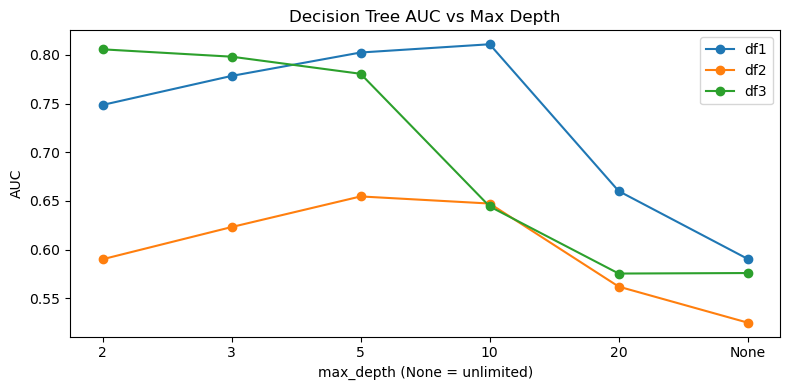

In [9]:
depths = [2, 3, 5, 10, 20, None]
aucs1_d, aucs2_d, aucs3_d = [], [], []

for d in depths:
    m1 = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X1_tr, y1_tr)
    aucs1_d.append(roc_auc_score(y1_te, m1.predict_proba(X1_te)[:, 1]))

    m2 = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X2_tr, y2_tr)
    aucs2_d.append(roc_auc_score(y2_te, m2.predict_proba(X2_te)[:, 1]))

    m3 = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X3_tr, y3_tr)
    aucs3_d.append(roc_auc_score(y3_te, m3.predict_proba(X3_te)[:, 1]))

labels = [str(d) for d in depths]
x = np.arange(len(depths))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, aucs1_d, marker='o', label='df1')
ax.plot(x, aucs2_d, marker='o', label='df2')
ax.plot(x, aucs3_d, marker='o', label='df3')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel('max_depth (None = unlimited)')
ax.set_ylabel('AUC')
ax.set_title('Decision Tree AUC vs Max Depth')
ax.legend()
plt.tight_layout()
plt.show()

## Visualize a Shallow Tree (df3, depth=3)

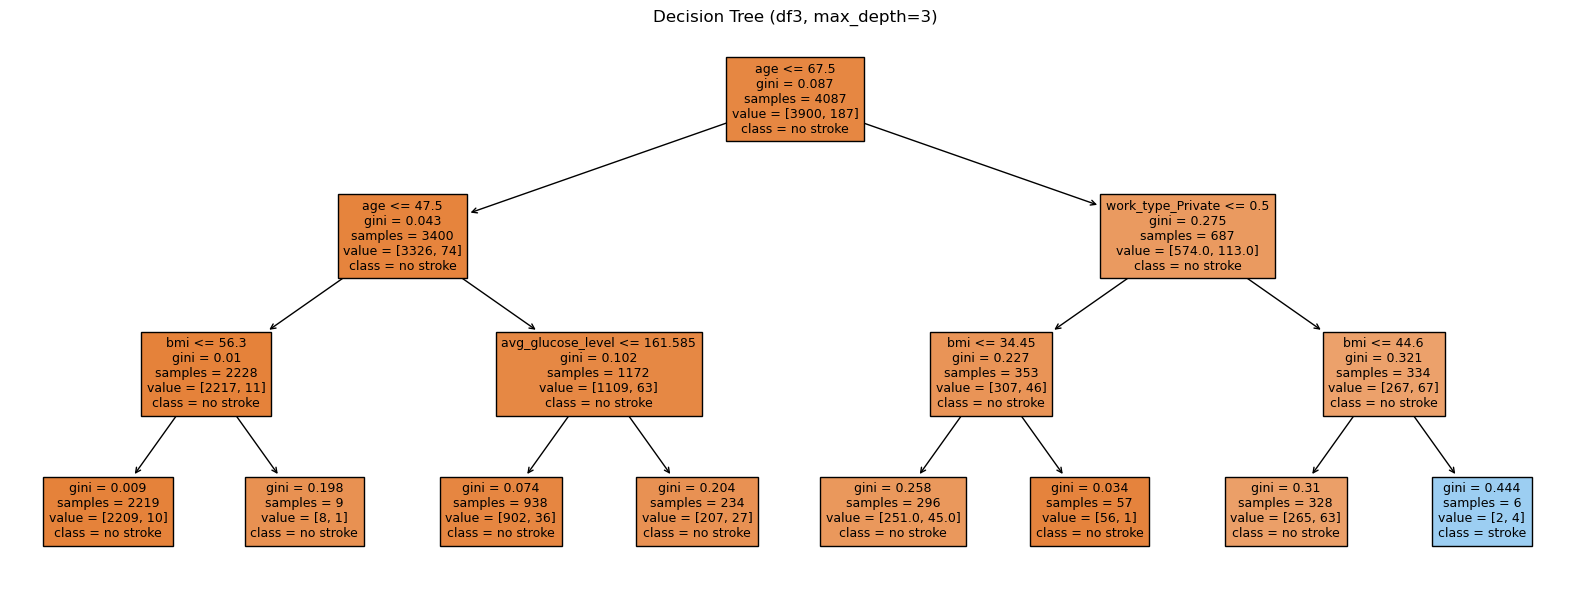

In [10]:
dt3_shallow = DecisionTreeClassifier(max_depth=3, random_state=42)
dt3_shallow.fit(X3_tr, y3_tr)

fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(dt3_shallow, feature_names=X3.columns.tolist(), class_names=['no stroke', 'stroke'],
          filled=True, ax=ax, fontsize=9)
plt.title('Decision Tree (df3, max_depth=3)')
plt.tight_layout()
plt.show()

## Random Forest

In [11]:
# df1
rf1 = RandomForestClassifier(n_estimators=100, random_state=42)
rf1.fit(X1_tr, y1_tr)
auc1_rf = roc_auc_score(y1_te, rf1.predict_proba(X1_te)[:, 1])
print(f'df1 RF AUC: {auc1_rf:.4f}')

df1 RF AUC: 0.7888


In [12]:
# df2
rf2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf2.fit(X2_tr, y2_tr)
auc2_rf = roc_auc_score(y2_te, rf2.predict_proba(X2_te)[:, 1])
print(f'df2 RF AUC: {auc2_rf:.4f}')

df2 RF AUC: 0.6535


In [13]:
# df3
rf3 = RandomForestClassifier(n_estimators=100, random_state=42)
rf3.fit(X3_tr, y3_tr)
auc3_rf = roc_auc_score(y3_te, rf3.predict_proba(X3_te)[:, 1])
print(f'df3 RF AUC: {auc3_rf:.4f}')

df3 RF AUC: 0.7947


## Feature Importances (Random Forest)

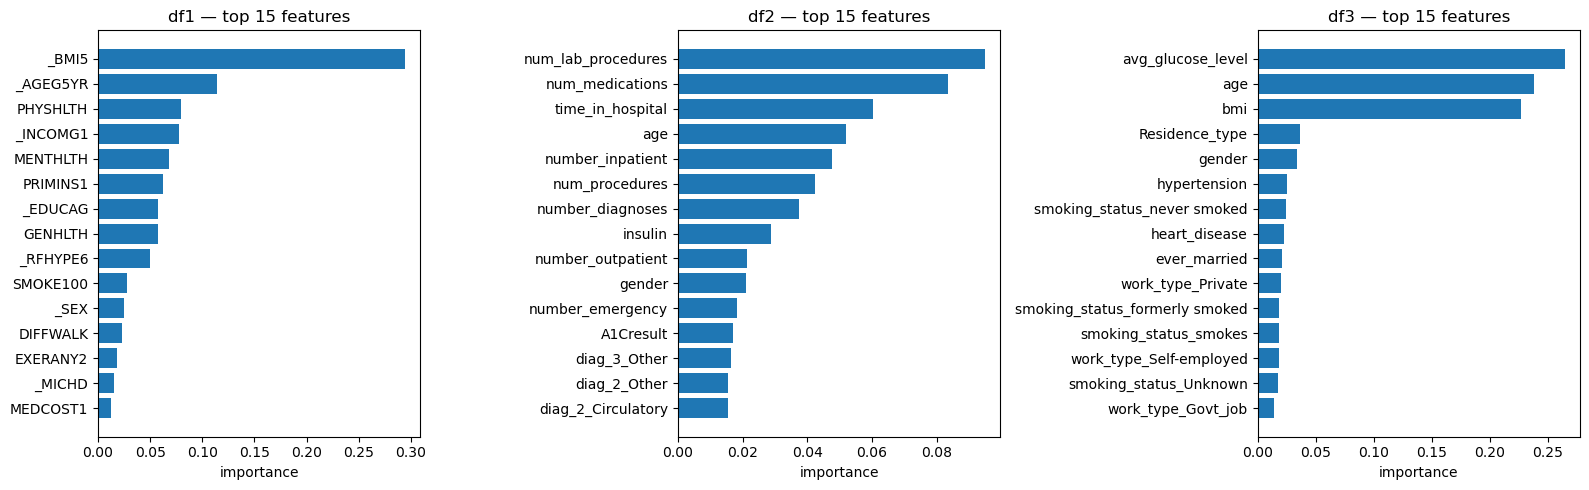

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, rf, X, label in zip(axes, [rf1, rf2, rf3], [X1, X2, X3], ['df1', 'df2', 'df3']):
    imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)[:15]
    ax.barh(imp.index[::-1], imp.values[::-1])
    ax.set_title(f'{label} — top 15 features')
    ax.set_xlabel('importance')

plt.tight_layout()
plt.show()

## ROC Curves — DT vs RF

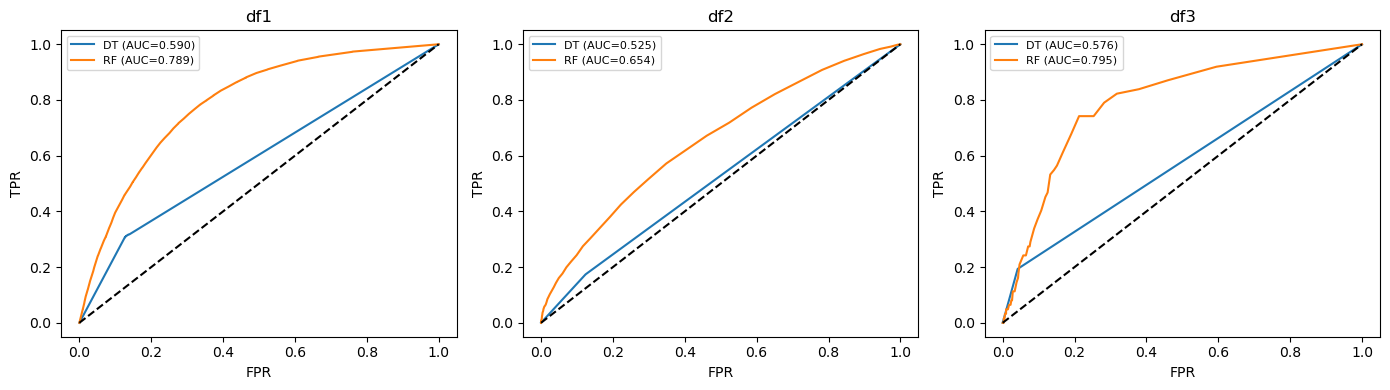

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, dt, rf, X_te, y_te, label in zip(
    axes,
    [dt1, dt2, dt3],
    [rf1, rf2, rf3],
    [X1_te, X2_te, X3_te],
    [y1_te, y2_te, y3_te],
    ['df1', 'df2', 'df3']
):
    for model, name in [(dt, 'DT'), (rf, 'RF')]:
        fpr, tpr, _ = roc_curve(y_te, model.predict_proba(X_te)[:, 1])
        auc = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])
        ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
    ax.plot([0,1],[0,1],'k--')
    ax.set_title(label)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## AUC Summary

Dataset  Decision Tree  Random Forest
    df1       0.590434       0.788766
    df2       0.524976       0.653515
    df3       0.575941       0.794666


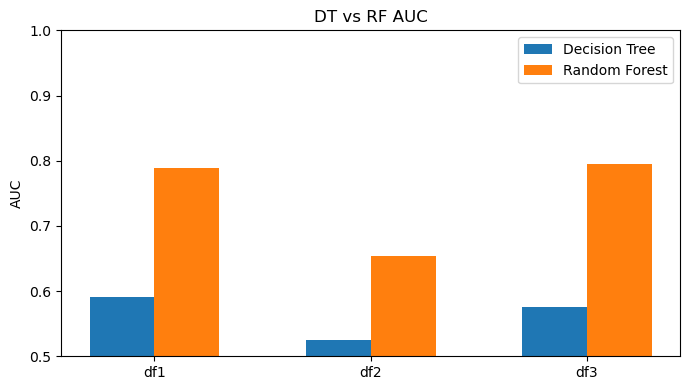

In [16]:
summary = pd.DataFrame({
    'Dataset': ['df1', 'df2', 'df3'],
    'Decision Tree': [auc1_dt, auc2_dt, auc3_dt],
    'Random Forest': [auc1_rf, auc2_rf, auc3_rf]
})
print(summary.to_string(index=False))

x = np.arange(3)
w = 0.3
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - w/2, summary['Decision Tree'], w, label='Decision Tree')
ax.bar(x + w/2, summary['Random Forest'], w, label='Random Forest')
ax.set_xticks(x)
ax.set_xticklabels(['df1', 'df2', 'df3'])
ax.set_ylabel('AUC')
ax.set_title('DT vs RF AUC')
ax.set_ylim(0.5, 1.0)
ax.legend()
plt.tight_layout()
plt.show()